# NPL with **Full State Space** (Cartesian product of bins)

This notebook fixes state enumeration to **all** (ia, iy, iage) triplets, not only those observed in the data.
It also provides robust fallbacks for rows of Π(j) with no observations and initial CCP rows P⁰ for states never observed.

In [1]:
import numpy as np, pandas as pd, json, itertools
CSV_PATH = "toy_panel.csv"
df = pd.read_csv(CSV_PATH)

BETA = 0.96
X_GRID = np.array([0.0,0.25,0.5,0.75,1.0]); J=len(X_GRID)
A_BINS, Y_BINS, AGE_BINS = 6,4,4
ALPHA = 5.0

In [2]:
EULER_GAMMA = 0.5772156649015329

def quantile_bins(series, nbins):
    qs = np.linspace(0,1,nbins+1)
    cuts = series.quantile(qs).values.astype(float)
    for i in range(1,len(cuts)):
        if cuts[i] <= cuts[i-1]:
            cuts[i] = cuts[i-1] + 1e-9
    return cuts

def cut_to_bins(x, cuts):
    return int(np.clip(np.searchsorted(cuts, x, side='right')-1, 0, len(cuts)-2))

def dirichlet_smooth(counts, alpha=5.0):
    counts = np.asarray(counts, float)
    prior = alpha/len(counts)
    return (counts + prior)/(counts.sum()+alpha)

def softmax(v):
    v = np.asarray(v, float); v = v - np.max(v)
    ex = np.exp(v); return ex/ex.sum()

In [3]:
# 1) Bin states & discretize action
a_cuts = quantile_bins(df['a'], A_BINS)
y_cuts = quantile_bins(df['y'], Y_BINS)
age_cuts = quantile_bins(df['age'], AGE_BINS)

dfb = df.copy()
dfb['ia'] = dfb['a'].apply(lambda v: cut_to_bins(v, a_cuts))
dfb['iy'] = dfb['y'].apply(lambda v: cut_to_bins(v, y_cuts))
dfb['iage'] = dfb['age'].apply(lambda v: cut_to_bins(v, age_cuts))

def x_to_j(x): 
    return int(np.argmin(np.abs(X_GRID - float(x))))
dfb['j'] = dfb['x'].apply(x_to_j)

# Add next-period states
dfb = dfb.sort_values(['id','t']).reset_index(drop=True)
for col in ['ia','iy','iage','j']:
    dfb[col+'_next'] = dfb.groupby('id')[col].shift(-1)
dfb = dfb.dropna(subset=['ia_next','iy_next','iage_next']).copy()
for col in ['ia_next','iy_next','iage_next','j_next']:
    dfb[col] = dfb[col].astype(int)

dfb.head()

,id,t,age,a,y,x,ia,iy,iage,j,ia_next,iy_next,iage_next,j_next
0,0,0,49,22578.384369,18562.351115,0.0,2,0,2,0,2,0,2,0
1,0,1,50,21927.092309,18448.435478,0.0,2,0,2,0,2,0,2,0
2,0,2,51,21828.647582,18243.992208,0.0,2,0,2,0,2,1,2,0
3,0,3,52,21654.901444,18939.917391,0.0,2,1,2,0,2,1,3,0
5,1,0,49,12187.260333,26335.488275,0.0,0,3,2,0,0,3,2,0


In [4]:
# 2) Enumerate the **full** state space S = A_BINS × Y_BINS × AGE_BINS
import itertools, numpy as np
states = [(ia,iy,iage) for ia,iy,iage in itertools.product(range(A_BINS), range(Y_BINS), range(AGE_BINS))]
S = len(states)
s_index = {s:i for i,s in enumerate(states)}

# Gather observed transition counts by action
J = len(X_GRID)
Pi_counts = [np.zeros((S,S), float) for _ in range(J)]
row_counts = [np.zeros(S, float) for _ in range(J)]
for _, r in dfb.iterrows():
    s  = s_index[(int(r.ia), int(r.iy), int(r.iage))]
    sp = s_index[(int(r.ia_next), int(r.iy_next), int(r.iage_next))]
    j  = int(r.j)
    Pi_counts[j][s, sp] += 1.0
    row_counts[j][s] += 1.0

# Build global next-state distributions by action (for fallback rows)
global_next_counts_by_j = [Pi_counts[j].sum(axis=0) for j in range(J)]
global_next_counts_all = sum(global_next_counts_by_j)

def safe_normalize(v):
    v = np.asarray(v, float)
    s = v.sum()
    if s <= 0:
        return np.ones_like(v)/len(v)
    return v/s

global_next_dist_by_j = [safe_normalize(c) for c in global_next_counts_by_j]
global_next_dist_all = safe_normalize(global_next_counts_all)

# 3) Normalize Π(j); fill zero-rows with global distributions
Pi = [np.zeros((S,S), float) for _ in range(J)]
for j in range(J):
    for s in range(S):
        if row_counts[j][s] > 0:
            Pi[j][s,:] = Pi_counts[j][s,:] / row_counts[j][s]
        else:
            base = global_next_dist_by_j[j]
            if base.sum() > 0:
                Pi[j][s,:] = base
            else:
                Pi[j][s,:] = global_next_dist_all

In [5]:
# 4) Initial CCPs P^0 on the **full** state space
counts = np.zeros((S,J), float)
for _, r in dfb.iterrows():
    s = s_index[(int(r.ia), int(r.iy), int(r.iage))]
    counts[s, int(r.j)] += 1.0

# Global fallback CCP
global_ccp = dirichlet_smooth(counts.sum(axis=0), alpha=ALPHA)
P = np.zeros((S,J), float)
for s in range(S):
    if counts[s,:].sum() > 0:
        P[s,:] = dirichlet_smooth(counts[s,:], alpha=ALPHA)
    else:
        P[s,:] = global_ccp  # unseen state: pooled prior CCPs

P[:3], P.shape

(array([[0.71428571, 0.07142857, 0.07142857, 0.07142857, 0.07142857],
        [0.73333333, 0.06666667, 0.06666667, 0.06666667, 0.06666667],
        [0.66666667, 0.08333333, 0.08333333, 0.08333333, 0.08333333]]),
 (96, 5))

In [6]:
# 5) Utility, EV1 correction, operators φ, Λ, Ψ
a_mids = np.array([0.5*(a_cuts[b]+a_cuts[b+1]) for b in range(len(a_cuts)-1)], float)

def u_vector(theta):
    k0,k1,phi = theta
    U = np.zeros((S,J), float)
    for si,(ia,iy,iage) in enumerate(states):
        a_mid = a_mids[ia]
        for j in range(1,J):
            U[si,j] = -(k0 + k1 + phi*a_mid)
        U[si,0] = 0.0
    return U

def correction_e(Pmat):
    eps = 1e-12
    return EULER_GAMMA - np.log(np.clip(Pmat, eps, 1.0))

def Pi_uncond(Pmat):
    M = np.zeros((S,S), float)
    for j in range(J):
        M += np.diag(Pmat[:,j]) @ Pi[j]
    return M

def phi(Pmat, theta):
    U = u_vector(theta)
    E = correction_e(Pmat)
    rhs = np.sum(Pmat * (U + E), axis=1)
    M = Pi_uncond(Pmat)
    I = np.eye(S)
    V = np.linalg.solve(I - BETA*M, rhs)
    return V

def Lambda(V, theta):
    U = u_vector(theta)
    idx = np.zeros_like(U)
    for j in range(J):
        idx[:,j] = U[:,j] + BETA * (Pi[j] @ V)
    Ptil = np.zeros_like(idx)
    for s in range(S):
        Ptil[s,:] = softmax(idx[s,:])
    return Ptil

def Psi(Pmat, theta):
    return Lambda(phi(Pmat, theta), theta)

In [11]:
# 6) Pseudo-likelihood and NPL loop
pairs = []
for _, r in dfb.iterrows():
    s = s_index[(int(r.ia), int(r.iy), int(r.iage))]
    pairs.append((s, int(r.j)))

def loglik_given_P(theta, Pk):
    Ptil = Psi(Pk, theta)
    eps=1e-12
    ll=0.0
    for (s,j) in pairs:
        ll += np.log(max(Ptil[s,j], eps))
    return ll, Ptil

def maximize_ll(Pk, theta0, steps=250, scales=None, seed=0):
    rng = np.random.default_rng(seed)
    if scales is None: scales = np.array([1.0,1.0,0.0005])
    theta = np.array(theta0, float)
    best_ll, best_P = loglik_given_P(theta, Pk)
    for it in range(steps):
        cand = theta + rng.normal(0, scales, size=3)
        ll, Ptil = loglik_given_P(cand, Pk)
        if ll > best_ll:
            theta, best_ll, best_P = cand, ll, Ptil
    return theta, best_ll, best_P

theta = np.array([15.0, 10.0, 0.005])
tol = 1e-4
history = []

Pk = P.copy()
for it in range(1000):
    theta, ll, Ptil = maximize_ll(Pk, theta, steps=250, scales=np.array([1.0,1.0,0.0005]), seed=it)
    supdiff = float(np.max(np.abs(Ptil - Pk)))
    history.append({'iter':it, 'll':float(ll), 'supnorm':supdiff, 'theta':list(map(float, theta))})
    Pk = Ptil
    if supdiff < tol:
        break

theta_hat = theta
P_hat = Pk
hist_df = pd.DataFrame(history)
hist_df.head()

/var/folders/ns/ty2gl9fs4lzg91dbkh3wyfzh0000gn/T/ipykernel_2786/2178614384.py:21: RuntimeWarning: divide by zero encountered in matmul
  M += np.diag(Pmat[:,j]) @ Pi[j]
/var/folders/ns/ty2gl9fs4lzg91dbkh3wyfzh0000gn/T/ipykernel_2786/2178614384.py:21: RuntimeWarning: overflow encountered in matmul
  M += np.diag(Pmat[:,j]) @ Pi[j]
/var/folders/ns/ty2gl9fs4lzg91dbkh3wyfzh0000gn/T/ipykernel_2786/2178614384.py:21: RuntimeWarning: invalid value encountered in matmul
  M += np.diag(Pmat[:,j]) @ Pi[j]
/var/folders/ns/ty2gl9fs4lzg91dbkh3wyfzh0000gn/T/ipykernel_2786/2178614384.py:37: RuntimeWarning: divide by zero encountered in matmul
  idx[:,j] = U[:,j] + BETA * (Pi[j] @ V)
/var/folders/ns/ty2gl9fs4lzg91dbkh3wyfzh0000gn/T/ipykernel_2786/2178614384.py:37: RuntimeWarning: overflow encountered in matmul
  idx[:,j] = U[:,j] + BETA * (Pi[j] @ V)
/var/folders/ns/ty2gl9fs4lzg91dbkh3wyfzh0000gn/T/ipykernel_2786/2178614384.py:37: RuntimeWarning: invalid value encountered in matmul
  idx[:,j] = U[:,j] 

,iter,ll,supnorm,theta
0,0,0.0,6.666667e-01,"[15.0, 10.0, 0.005]"
1,1,0.0,7.616895e-41,"[15.0, 10.0, 0.005]"


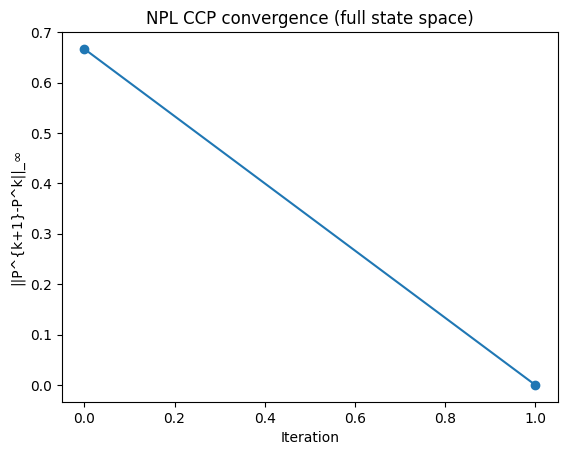

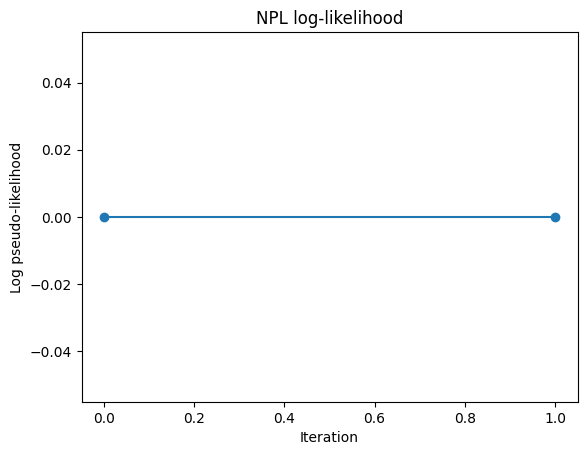

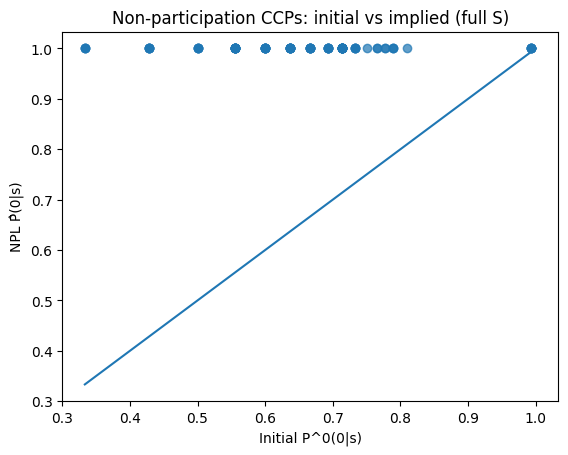

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(hist_df['iter'].values, hist_df['supnorm'].values, marker='o')
plt.xlabel('Iteration'); plt.ylabel('||P^{k+1}-P^k||_∞'); plt.title('NPL CCP convergence (full state space)')
plt.show()

plt.figure()
plt.plot(hist_df['iter'].values, hist_df['ll'].values, marker='o')
plt.xlabel('Iteration'); plt.ylabel('Log pseudo-likelihood'); plt.title('NPL log-likelihood')
plt.show()

emp_P0 = P[:,0].copy()
imp_P0 = P_hat[:,0].copy()
plt.figure()
plt.scatter(emp_P0, imp_P0, alpha=0.7)
mn = min(emp_P0.min(), imp_P0.min()); mx = max(emp_P0.max(), imp_P0.max())
plt.plot([mn,mx],[mn,mx])
plt.xlabel('Initial P^0(0|s)'); plt.ylabel('NPL P̂(0|s)'); plt.title('Non-participation CCPs: initial vs implied (full S)')
plt.show()